# BAMv3 실험: 노이즈→노이즈 학습

**Ultra-low SNR 환경을 위한 Robust Feature Learning**
- Self-supervised 학습 방식
- 다양한 SNR에서 일관된 패턴 학습
- 병목 효과로 랜덤 노이즈 제거
- 노이즈 범위 줄임(5~-5db)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv3
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)


/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
from scipy.signal import stft, istft, resample

STFT_PARAMS = {
    'nperseg': 128,
    'noverlap': 64,
    'window': 'hann'
}

def generate_complex_spectrogram(iq_signal, fs, bw=250_000):
    """
    복소 IQ 신호 → STFT 기반 complex 스펙트로그램 생성 (재학습용)
    - stft() / istft()가 1:1로 대응되도록 설계
    """
    nperseg  = STFT_PARAMS['nperseg']
    noverlap = STFT_PARAMS['noverlap']
    window   = STFT_PARAMS['window']

    # 1) STFT (spectrogram 대신 stft 사용)
    f, t, Zxx = stft(
        iq_signal,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary=None,          # padding 안 함
        padded=False,
        return_onesided=False   # 복소 baseband 이므로 False
    )

    # 2) 주파수축 shift 후 BW 크롭
    f_shifted    = np.fft.fftshift(f)
    Zxx_shifted  = np.fft.fftshift(Zxx, axes=0)
    original_shape = Zxx_shifted.shape

    mask = (f_shifted >= -bw/2) & (f_shifted < bw/2)
    freq_indices = np.where(mask)[0]
    Zxx_cropped  = Zxx_shifted[mask, :]   # (F_bw, T)

    # 3) Real / Imag 분리 + min-max 정규화
    real_part = Zxx_cropped.real
    imag_part = Zxx_cropped.imag

    r_min, r_max = real_part.min(), real_part.max()
    i_min, i_max = imag_part.min(), imag_part.max()

    real_norm = (real_part - r_min) / (r_max - r_min + 1e-12)
    imag_norm = (imag_part - i_min) / (i_max - i_min + 1e-12)

    # 4) 플랫 벡터로 합치기
    real_flat = real_norm.flatten()
    imag_flat = imag_norm.flatten()
    combined_flat = np.concatenate([real_flat, imag_flat])

    # 5) 복원을 위한 메타 정보 저장
    norm_params = {
        'r_min': r_min, 'r_max': r_max,
        'i_min': i_min, 'i_max': i_max,
        'shape': Zxx_cropped.shape,        # (F_bw, T)
        'original_shape': original_shape,  # full Zxx shape
        'freq_indices': freq_indices,
        'stft_params': STFT_PARAMS.copy(),
        'orig_len': len(iq_signal),        # 원래 IQ 길이 (예: 2048)
    }

    return combined_flat, norm_params

def reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs):
    """
    BAM 복원 스펙트로그램(flat) → complex STFT → ISTFT → IQ 신호
    (재학습 버전용)
    """
    cropped_shape = norm_params['shape']   # (F_bw, T)
    mid = len(restored_flat) // 2

    # 1) Real/Imag 복원 + reshape
    real_restored_norm = restored_flat[:mid].reshape(cropped_shape)
    imag_restored_norm = restored_flat[mid:].reshape(cropped_shape)

    # 2) 역정규화
    real_restored = (
        real_restored_norm * (norm_params['r_max'] - norm_params['r_min'])
        + norm_params['r_min']
    )
    imag_restored = (
        imag_restored_norm * (norm_params['i_max'] - norm_params['i_min'])
        + norm_params['i_min']
    )

    Zxx_cropped = real_restored + 1j * imag_restored   # (F_bw, T)

    # 3) full STFT 행렬로 복원
    Zxx_full = np.zeros(norm_params['original_shape'], dtype=complex)
    Zxx_full[norm_params['freq_indices'], :] = Zxx_cropped

    # 4) ifftshift로 원래 STFT 형태로 되돌림
    Zxx_unshifted = np.fft.ifftshift(Zxx_full, axes=0)

    # 5) ISTFT (STFT와 완전히 동일한 파라미터 사용)
    stft_params = norm_params['stft_params']
    _, iq_restored = istft(
        Zxx_unshifted,
        fs=fs,
        window=stft_params['window'],
        nperseg=stft_params['nperseg'],
        noverlap=stft_params['noverlap'],
        input_onesided=False,
        boundary=None,
    )

    # 6) 길이 보정 (pad/crop만, resample 사용 ❌)
    target_len = norm_params.get('orig_len', len(iq_restored))

    if len(iq_restored) > target_len:
        iq_restored = iq_restored[:target_len]
    elif len(iq_restored) < target_len:
        iq_restored = np.pad(iq_restored, (0, target_len - len(iq_restored)), mode='edge')

    return iq_restored

In [3]:
# LoRa 파라미터 설정
sf = 9
bw = 250_000  # 250 kHz
OSF = 4
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf, bw)


SF = 9, BW = 250.0 kHz, fs = 1.000 MHz


In [4]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v3_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 2048), dtype: complex64


In [5]:
########################################
##  2. 데이터 증강 함수 정의          ##
########################################

# SNR 범위 설정 (SNR에 집중)
SNR_MIN = -5
SNR_MAX = 5
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def augment_dataset(X_clean_iq, augment_factor=30):
    """
    클린 IQ를 N배로 증강 (매번 다른 랜덤 노이즈 추가)
    Complex 스펙트로그램 사용 (Phase 정보 보존)
    
    Returns:
        X_noisy_flat: (512*augment_factor, input_dim) 형태
        norm_params_list: 각 샘플의 역정규화 파라미터
    """
    print(f"\nGenerating {len(X_clean_iq)} × {augment_factor} = {len(X_clean_iq) * augment_factor} augmented samples...")
    
    X_noisy_flat_list = []
    norm_params_list = []
    
    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            # 랜덤 SNR 선택
            snr = np.random.randint(SNR_MIN, SNR_MAX + 1)
            
            # 노이즈 추가
            noisy_iq = lora.awgn_iq(clean_iq, snr)
            
            # Complex 스펙트로그램 생성 (Phase 보존)
            spec_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)
            X_noisy_flat_list.append(spec_flat)
            norm_params_list.append(norm_params)
    
    X_noisy_flat = np.array(X_noisy_flat_list)
    
    print(f"Augmented dataset shape: {X_noisy_flat.shape}")
    print(f"  - Real/Imag combined (Phase preserved)")
    
    return X_noisy_flat, norm_params_list

print(f"✅ Complex augmentation function defined: {AUGMENT_FACTOR}x per clean IQ")


✅ Complex augmentation function defined: 30x per clean IQ


In [ ]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축: 7936 → 4096 → 3072 → 2048
layers = [input_dim, 4096, 2048, 1024,512]
#layers = [1984, 4096, 2048, 512]
print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {' → '.join(map(str, layers))}")
print(f"Compression ratio: {input_dim / layers[-1]:.1f}x")
print(f"Layers: {len(layers)-1} BAM layers (더 부드러운 압축)")


Complex spectrogram shape: (32, 31)
Input dim (Real+Imag): 1984
Model architecture: 1984 → 4096 → 2048 → 512
Compression ratio: 3.9x
Layers: 3 BAM layers (더 부드러운 압축)



=== Training BAMv3 Model (Complex Spectrogram) ===
Architecture: 1984 → 4096 → 2048 → 512
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)

=== Starting Training with On-the-fly Complex Augmentation ===
Base samples: 512
Augmentation factor: 30x
Total per epoch: 15360

Epoch 1/20

Generating 512 × 30 = 15360 augmented samples...
Augmented dataset shape: (15360, 1984)
  - Real/Imag combined (Phase preserved)

--- Training Layer 1/3 ---
Epoch 1, Batch 1/240, MSE = 0.019499
Epoch 1, Batch 2/240, MSE = 0.006940
Epoch 1, Batch 3/240, MSE = 0.007446
Epoch 1, Batch 4/240, MSE = 0.008027
Epoch 1, Batch 5/240, MSE = 0.007649
Epoch 1, Batch 6/240, MSE = 0.007857
Epoch 1, Batch 7/240, MSE = 0.008115
Epoch 1, Batch 8/240, MSE = 0.007971
Epoch 1, Batch 9/240, MSE = 0.007530
Epoch 1, Batch 10/240, MSE = 0.007900
Epoch 1, Batch 11/240, MSE = 0.007814
Epoch 1, Batch 12/240, MSE = 0.007705
Epoch 1, Batch 13/240, MSE = 0.007128
Epoch 1, Batch 14/240, MSE = 0.006894
Epoch 1, Batch 15/24

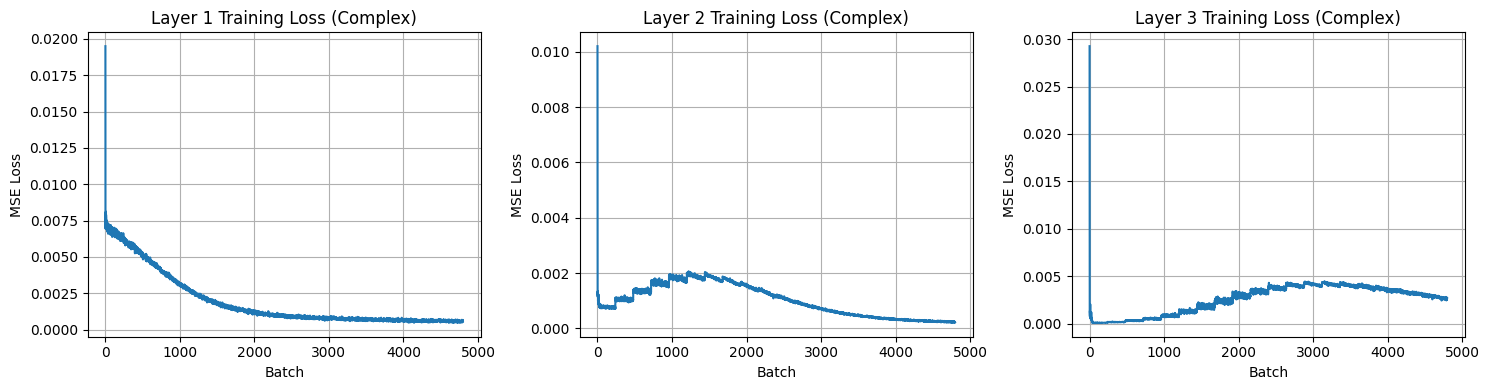

In [7]:
########################################
##  4. BAMv3 Complex 30배 증강 학습  ##
########################################

print(f"\n=== Training BAMv3 Model (Complex Spectrogram) ===")
print(f"Architecture: {' → '.join(map(str, layers))}")
print(f"Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)")

# BAMv3 모델 생성 (학습률 조정: 3-layer BAM에 적합한 lr)
model = MultiBAMv3(layers_dims=layers, eta=5e-4)

# 학습 플래그
TRAIN = True  # 테스트 전에는 False

if TRAIN:
    print("\n=== Starting Training with On-the-fly Complex Augmentation ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    print(f"Total per epoch: {len(X_clean_iq) * AUGMENT_FACTOR}")
    
    # 학습 파라미터
    num_epochs = 20
    batch_size = 64
    
    all_layer_losses = [[] for _ in range(len(layers)-1)]
    
    # 매 epoch마다 새로운 노이즈로 증강
    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")
        
        # 30배 증강된 Complex 데이터 생성 (매 epoch마다 다른 노이즈!)
        X_augmented, _ = augment_dataset(X_clean_iq, AUGMENT_FACTOR)
        
        # 1 epoch만 학습 (이미 증강된 데이터로)
        layer_losses = model.train(X_augmented, num_epochs=1, batch_size=batch_size)
        
        # Loss 기록
        for i, losses in enumerate(layer_losses):
            all_layer_losses[i].extend(losses)
    
    print("\n=== Training Complete ===")
    
    # Loss 플롯 (각 layer별)
    fig, axes = plt.subplots(1, len(all_layer_losses), figsize=(15, 4))
    if len(all_layer_losses) == 1:
        axes = [axes]
    
    for i, losses in enumerate(all_layer_losses):
        axes[i].plot(losses)
        axes[i].set_xlabel('Batch')
        axes[i].set_ylabel('MSE Loss')
        axes[i].set_title(f'Layer {i+1} Training Loss (Complex)')
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nTraining skipped (TRAIN=False)")


In [8]:
########################################
##  5. 모델 저장                     ##
########################################

import torch

if TRAIN:
    # 모델 저장 폴더
    weight_folder = "weights_bamv3_complex"
    os.makedirs(weight_folder, exist_ok=True)
    
    # 각 layer의 weight 저장
    for i, bam in enumerate(model.bams):
        weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
        np.save(weight_path, bam.W.cpu().numpy())
        print(f"✅ Layer {i} weights saved to: {weight_path}")
    
    # 아키텍처 정보 저장
    config = {
        'layers': layers,
        'eta': 5e-4,
        'sf': sf,
        'bw': bw,
        'fs': fs,
        'mode': 'complex'  # Complex 방식 표시
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")

print("\n=== How to Load Model ===")
print("""
# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))
""")


✅ Layer 0 weights saved to: weights_bamv3_complex/weights_layer_0.npy
✅ Layer 1 weights saved to: weights_bamv3_complex/weights_layer_1.npy
✅ Layer 2 weights saved to: weights_bamv3_complex/weights_layer_2.npy
✅ Config saved to: weights_bamv3_complex/model_config.npy

=== How to Load Model ===

# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))



In [9]:
########################################
##  5-1. 학습된 모델 로드 (TRAIN=False일 때)  ##
########################################

import torch

# TRAIN=False인 경우에만 저장된 모델 로드
if not TRAIN:
    weight_folder = "weights_bamv3_complex"
    
    # Config 파일이 존재하는지 확인
    config_path = os.path.join(weight_folder, "model_config.npy")
    
    if os.path.exists(config_path):
        print(f"\n=== Loading Pre-trained Model ===")
        
        # Config 로드
        config = np.load(config_path, allow_pickle=True).item()
        print(f"Loaded config: {config}")
        
        # 아키텍처가 동일한지 확인
        if config['layers'] == layers:
            # 각 layer의 weight 로드
            for i, bam in enumerate(model.bams):
                weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
                if os.path.exists(weight_path):
                    loaded_weight = np.load(weight_path)
                    # 🔧 디바이스 지정 추가! (CPU/CUDA 자동 감지)
                    bam.W = torch.tensor(loaded_weight, dtype=torch.float32).to(bam.device)
                    print(f"✅ Layer {i} weights loaded from: {weight_path} (device: {bam.device})")
                else:
                    print(f"❌ Warning: {weight_path} not found!")
            
            print(f"✅ Model successfully loaded from {weight_folder}")
        else:
            print(f"❌ Warning: Architecture mismatch!")
            print(f"   Current: {layers}")
            print(f"   Saved:   {config['layers']}")
    else:
        print(f"❌ Warning: No pre-trained model found in {weight_folder}")
        print(f"   Please set TRAIN=True to train a new model first.")
else:
    print("\n=== Using Newly Trained Model ===")
    print("Model weights from training will be used.")



=== Using Newly Trained Model ===
Model weights from training will be used.



=== Testing Complex Reconstruction ===
Test symbol: 42, SNR: -10 dB

=== Normalization Parameters ===
Real: min=-1.164391, max=1.053471, range=2.217862
Imag: min=-1.360611, max=1.399853, range=2.760464
Restored norm: real_min=0.2137, real_max=0.8096
Restored norm: imag_min=0.2155, imag_max=0.8014
After denorm:  real_min=-0.690544, real_max=0.631081
After denorm:  imag_min=-0.765600, imag_max=0.851688
✅ IQ signal reconstructed: (2048,)

=== Debug: Values Check ===
Noisy flat:    min=0.0000, max=1.0000, mean=0.5088
Restored flat: min=0.2137, max=0.8096, mean=0.5086
Difference:    MSE=0.007960


/tmp/ipykernel_82362/772892593.py:100: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


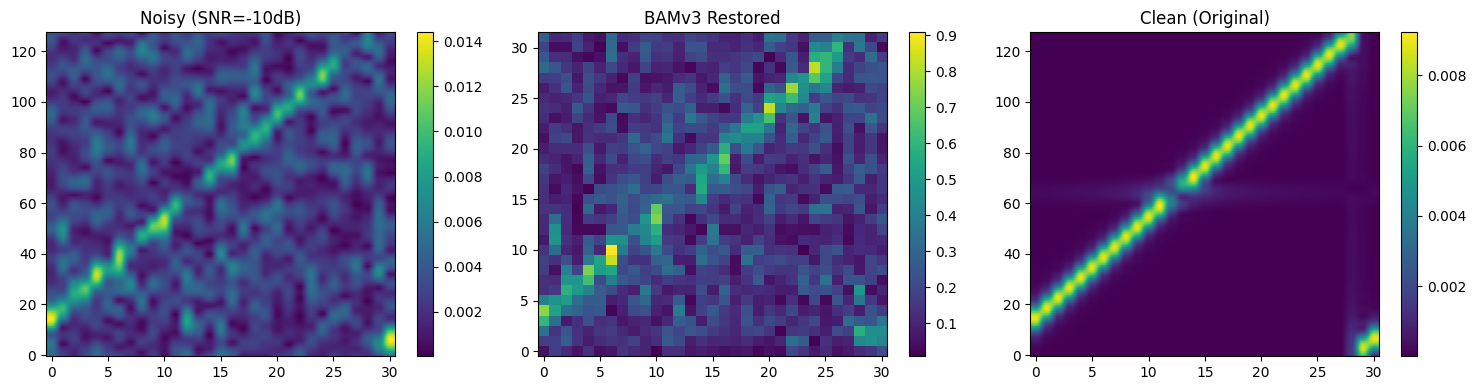


=== Spectrogram Magnitude Check ===
Zxx_noisy (magnitude):    min=0.0000, max=0.0144
Zxx_restored (magnitude): min=0.0085, max=0.9079
Zxx_clean (magnitude):    min=0.0000, max=0.0092


In [10]:
########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

# 테스트 샘플 선택
test_symbol = 42  # 테스트할 심볼 (0~511)
test_snr = -10    # 테스트 SNR

print(f"\n=== Testing Complex Reconstruction ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

# 1. 클린 IQ 생성
clean_iq = X_clean_iq[test_symbol]

# 2. 노이즈 추가
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 3. Complex 스펙트로그램 생성
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

# 4. BAM 압축/복원
compressed = model.compress(noisy_flat.reshape(1, -1))
restored_flat = model.decompress(compressed).flatten()

# 5. Real/Imag 분리 및 역정규화 (학습 시와 동일한 스케일 사용)
mid = len(restored_flat) // 2
real_restored_norm = restored_flat[:mid].reshape(norm_params['shape'])
imag_restored_norm = restored_flat[mid:].reshape(norm_params['shape'])

# 🔍 정규화 파라미터 확인
print(f"\n=== Normalization Parameters ===")
print(f"Real: min={norm_params['r_min']:.6f}, max={norm_params['r_max']:.6f}, range={norm_params['r_max']-norm_params['r_min']:.6f}")
print(f"Imag: min={norm_params['i_min']:.6f}, max={norm_params['i_max']:.6f}, range={norm_params['i_max']-norm_params['i_min']:.6f}")
print(f"Restored norm: real_min={real_restored_norm.min():.4f}, real_max={real_restored_norm.max():.4f}")
print(f"Restored norm: imag_min={imag_restored_norm.min():.4f}, imag_max={imag_restored_norm.max():.4f}")

# 역정규화 (Noisy 범위 사용 - 학습 시와 일관성 유지)
real_restored = real_restored_norm * (norm_params['r_max'] - norm_params['r_min']) + norm_params['r_min']
imag_restored = imag_restored_norm * (norm_params['i_max'] - norm_params['i_min']) + norm_params['i_min']

print(f"After denorm:  real_min={real_restored.min():.6f}, real_max={real_restored.max():.6f}")
print(f"After denorm:  imag_min={imag_restored.min():.6f}, imag_max={imag_restored.max():.6f}")

# 6. Complex 재결합
Zxx_restored = real_restored + 1j * imag_restored

# 7. IQ 신호 복원
iq_reconstructed = reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs)

print(f"✅ IQ signal reconstructed: {iq_reconstructed.shape}")

# 8. 길이 맞추기: Resample
target_len = len(clean_iq)
if len(iq_reconstructed) != target_len:
    iq_reconstructed = resample(iq_reconstructed, target_len)

# [추천] 에너지 정규화 추가 (표준편차를 1로 맞춤) -> 볼륨 자동 조절 효과
iq_reconstructed = iq_reconstructed / (np.std(iq_reconstructed) + 1e-12)

# 또는 (최댓값을 1로 맞춤)
# iq_reconstructed = iq_reconstructed / (np.max(np.abs(iq_reconstructed)) + 1e-12)

# 🔍 디버깅: 값 확인
print(f"\n=== Debug: Values Check ===")
print(f"Noisy flat:    min={noisy_flat.min():.4f}, max={noisy_flat.max():.4f}, mean={noisy_flat.mean():.4f}")
print(f"Restored flat: min={restored_flat.min():.4f}, max={restored_flat.max():.4f}, mean={restored_flat.mean():.4f}")
mse_diff = ((noisy_flat - restored_flat)**2).mean()
print(f"Difference:    MSE={mse_diff:.6f}")

# 시각화: Magnitude 스펙트로그램 비교 (모두 같은 파라미터 + BW 크롭)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Noisy 스펙트로그램 (BW 크롭 적용)
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
mask_n = (f_n >= -bw/2) & (f_n < bw/2)
Zxx_noisy = Zxx_noisy_full[mask_n, :]
im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

# Restored 스펙트로그램 (이미 크롭됨)
im2 = axes[1].imshow(np.abs(Zxx_restored), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('BAMv3 Restored')
plt.colorbar(im2, ax=axes[1])

# Clean 스펙트로그램 (BW 크롭 적용)
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
mask_c = (f_c >= -bw/2) & (f_c < bw/2)
Zxx_clean = Zxx_clean_full[mask_c, :]
im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title('Clean (Original)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# 🔍 스펙트로그램 magnitude 확인
print(f"\n=== Spectrogram Magnitude Check ===")
print(f"Zxx_noisy (magnitude):    min={np.abs(Zxx_noisy).min():.4f}, max={np.abs(Zxx_noisy).max():.4f}")
print(f"Zxx_restored (magnitude): min={np.abs(Zxx_restored).min():.4f}, max={np.abs(Zxx_restored).max():.4f}")
print(f"Zxx_clean (magnitude):    min={np.abs(Zxx_clean).min():.4f}, max={np.abs(Zxx_clean).max():.4f}")


In [11]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 🔍 IQ 신호 차이 분석
print(f"\n=== IQ Signal Analysis ===")
print(f"Clean IQ:        len={len(clean_iq)}, |mean|={np.abs(clean_iq).mean():.4f}, |max|={np.abs(clean_iq).max():.4f}")
print(f"Noisy IQ:        len={len(noisy_iq)}, |mean|={np.abs(noisy_iq).mean():.4f}, |max|={np.abs(noisy_iq).max():.4f}")
print(f"Reconstructed:   len={len(iq_reconstructed)}, |mean|={np.abs(iq_reconstructed).mean():.4f}, |max|={np.abs(iq_reconstructed).max():.4f}")

# MSE 비교 (길이 맞춤)
min_len = min(len(clean_iq), len(noisy_iq), len(iq_reconstructed))
mse_clean_noisy = np.mean(np.abs(clean_iq[:min_len] - noisy_iq[:min_len])**2)
mse_clean_recon = np.mean(np.abs(clean_iq[:min_len] - iq_reconstructed[:min_len])**2)
mse_noisy_recon = np.mean(np.abs(noisy_iq[:min_len] - iq_reconstructed[:min_len])**2)

print(f"\nMSE Comparison:")
print(f"Clean vs Noisy:        {mse_clean_noisy:.6f}")
print(f"Clean vs Reconstructed: {mse_clean_recon:.6f}")
print(f"Noisy vs Reconstructed: {mse_noisy_recon:.6f}")

# Dechirp 및 심볼 복원 테스트
print(f"\n=== Dechirp Symbol Decoding ===")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, "clean", sf, fs, bw)
print(f"✅ Clean signal (len={len(clean_iq)})    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, "noisy", sf, fs, bw)
print(f"⚠️  Noisy signal (len={len(noisy_iq)})    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAM 복원 신호 Dechirp (Resample 적용 완료!)
code_restored, peak_restored = estimate_symbol_custom(iq_reconstructed, "restored", sf, fs, bw)
print(f"🔧 Restored (len={len(iq_reconstructed)})   → Code: {code_restored}, Peak: {peak_restored:.2f}")

# 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Restored Decoded:    {code_restored} {'✅ CORRECT' if code_restored == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Restored Peak: {peak_restored:.2f} ({peak_restored/peak_clean*100:.1f}% of clean)")

if code_restored == test_symbol:
    print(f"\n✅ SUCCESS: BAMv3 successfully restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv3 failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===

=== IQ Signal Analysis ===
Clean IQ:        len=2048, |mean|=1.0000, |max|=1.0000
Noisy IQ:        len=2048, |mean|=2.9642, |max|=8.5047
Reconstructed:   len=2048, |mean|=0.2384, |max|=32.4171

MSE Comparison:
Clean vs Noisy:        9.947623
Clean vs Reconstructed: 1.769339
Noisy vs Reconstructed: 11.405217

=== Dechirp Symbol Decoding ===
✅ Clean signal (len=2048)    → Code: 42, Peak: 1880.00
⚠️  Noisy signal (len=2048)    → Code: 42, Peak: 1920.58
🔧 Restored (len=2048)   → Code: 42, Peak: 272.61

Performance Evaluation:
Ground Truth Symbol: 42
Clean Decoded:       42 ✅ CORRECT
Noisy Decoded:       42 ✅ CORRECT
Restored Decoded:    42 ✅ CORRECT

Peak Comparison:
Clean Peak:    1880.00
Noisy Peak:    1920.58 (102.2% of clean)
Restored Peak: 272.61 (14.5% of clean)

✅ SUCCESS: BAMv3 successfully restored the correct symbol!



📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)

🧪 Testing with 100 samples at each SNR level...
SNR levels: [-25, -20, -15, -10, -5] dB


──────────────────────────────────────────────────────────────────────
Testing SNR = -25 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_82362/772892593.py:100: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Baseline Accuracy (noisy→FFT): 10.0%
  ✓ BAM Accuracy      (restored): 3.0%
  ✓ BAM Avg MSE (clean vs restored IQ): 221.803702
  ✓ Peak Ratio (Baseline/BAM vs Clean): 590.8% / 430.5%

──────────────────────────────────────────────────────────────────────
Testing SNR = -20 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Accuracy (noisy→FFT): 37.0%
  ✓ BAM Accuracy      (restored): 11.0%
  ✓ BAM Avg MSE (clean vs restored IQ): 75.569166
  ✓ Peak Ratio (Baseline/BAM vs Clean): 244.5% / 183.1%

──────────────────────────────────────────────────────────────────────
Testing SNR = -15 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Accuracy (noisy→FFT): 72.0%
  ✓ BAM Accuracy      (restored): 42.0%
  ✓ BAM Avg MSE (clean vs restored IQ): 29.844650
  ✓ Peak Ratio (Baseline/BAM vs Clean): 170.8% / 117.9%

──────────────────────────────────────────────────────────────────────
Testing SNR = -10 dB
──────────────────

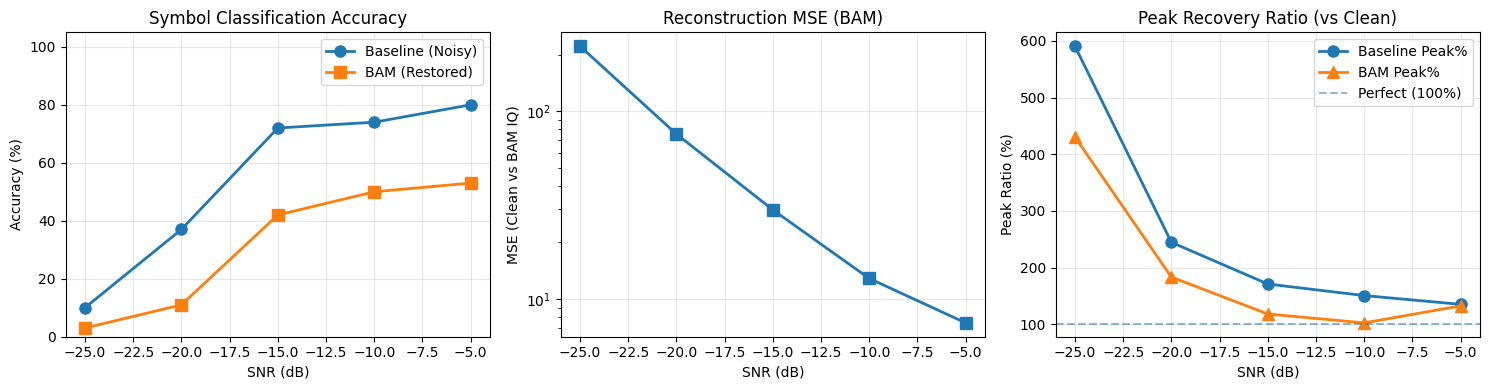


✅ Quantitative evaluation (Baseline vs BAM) complete!


In [12]:
########################################
##  8. 정량적 성능 평가 (다중 샘플)  ##
########################################

def match_length(x, target_len):
    """앞쪽은 건드리지 말고, 뒤쪽만 잘라내거나 패딩해서 길이 맞춤"""
    cur_len = len(x)
    if cur_len > target_len:
        # 뒤에서 자르기
        return x[:target_len]
    elif cur_len < target_len:
        pad_len = target_len - cur_len
        # 뒤쪽에만 패딩 (0 또는 edge 중 취향)
        return np.pad(x, (0, pad_len), mode='edge')
        # 또는: return np.pad(x, (0, pad_len), mode='constant', constant_values=0)
    else:
        return x

print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)")
print("="*70)

# 테스트 파라미터
NUM_TEST_SAMPLES = 100  # 테스트할 샘플 수 (각 SNR별)
TEST_SNR_LEVELS = [-25, -20, -15, -10, -5]  # 다양한 SNR 레벨

# 결과 저장용 딕셔너리
results = {
    snr: {
        # BAM 경로
        'bam_correct': 0,
        'bam_total': 0,
        'bam_mse': [],
        'bam_peak_ratio': [],

        # Baseline 경로 (noisy → dechirp+FFT)
        'base_correct': 0,
        'base_total': 0,
        'base_peak_ratio': [],
    }
    for snr in TEST_SNR_LEVELS
}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")
    
    for i in range(NUM_TEST_SAMPLES):
        # 랜덤 심볼 선택
        test_sym = np.random.randint(0, 512)
        
        # 1. 클린 IQ
        clean_iq_test = X_clean_iq[test_sym]
        
        # 2. 노이즈 추가
        noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
        
        # 3. Complex 스펙트로그램 생성 (noisy → BAM 입력)
        noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)
        
        # 4. BAMv3 복원 (compress -> decompress)
        compressed = model.compress(noisy_flat.reshape(1, -1))
        restored_flat = model.decompress(compressed).flatten()
        
        # 5. IQ 신호 재구성 (BAM 경로)
        iq_restored = reconstruct_iq_from_spectrogram(restored_flat, noisy_params, fs)

        target_len = len(clean_iq_test)
        iq_restored = match_length(iq_restored, target_len)
        
        # 6. Dechirp 및 심볼 추정
        try:
            # 기준: 클린 신호 (peak scale 기준용)
            code_clean, peak_clean = estimate_symbol_custom(clean_iq_test, "clean", sf, fs, bw)
            
            # Baseline: noisy 신호 직접 디코딩
            code_base, peak_base = estimate_symbol_custom(noisy_iq_test, "noisy", sf, fs, bw)
            
            # BAM 경로: 복원된 IQ로 디코딩
            code_bam, peak_bam = estimate_symbol_custom(iq_restored, "restored", sf, fs, bw)
            
            # -----------------------------
            # Baseline 정확도 기록
            # -----------------------------
            if code_base == test_sym:
                results[snr]['base_correct'] += 1
            results[snr]['base_total'] += 1
            
            # -----------------------------
            # BAM 정확도 기록
            # -----------------------------
            if code_bam == test_sym:
                results[snr]['bam_correct'] += 1
            results[snr]['bam_total'] += 1
            
            # -----------------------------
            # Peak Ratio 기록 (clean 대비)
            # -----------------------------
            if peak_clean > 0:
                results[snr]['base_peak_ratio'].append(peak_base / peak_clean)
                results[snr]['bam_peak_ratio'].append(peak_bam / peak_clean)
            
            # -----------------------------
            # BAM 복원 IQ 기준 MSE (clean vs restored)
            # -----------------------------
            mse = np.mean(np.abs(iq_restored - clean_iq_test)**2)
            results[snr]['bam_mse'].append(mse)
            
        except Exception as e:
            print(f"  ⚠️ Error at sample {i}: {e}")
            # baseline/bam 둘 다 total 증가
            results[snr]['base_total'] += 1
            results[snr]['bam_total'] += 1
    
    # 중간 결과 출력
    base_acc = (results[snr]['base_correct'] / results[snr]['base_total'] * 100
                if results[snr]['base_total'] > 0 else 0.0)
    bam_acc = (results[snr]['bam_correct'] / results[snr]['bam_total'] * 100
               if results[snr]['bam_total'] > 0 else 0.0)
    
    avg_mse = np.mean(results[snr]['bam_mse']) if results[snr]['bam_mse'] else 0
    avg_base_peak = (np.mean(results[snr]['base_peak_ratio']) * 100
                     if results[snr]['base_peak_ratio'] else 0)
    avg_bam_peak = (np.mean(results[snr]['bam_peak_ratio']) * 100
                    if results[snr]['bam_peak_ratio'] else 0)
    
    print(f"  ✓ Baseline Accuracy (noisy→FFT): {base_acc:.1f}%")
    print(f"  ✓ BAM Accuracy      (restored): {bam_acc:.1f}%")
    print(f"  ✓ BAM Avg MSE (clean vs restored IQ): {avg_mse:.6f}")
    print(f"  ✓ Peak Ratio (Baseline/BAM vs Clean): {avg_base_peak:.1f}% / {avg_bam_peak:.1f}%")

# 최종 결과 요약
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY (Baseline vs BAM)")
print("="*70)

print(f"\n{'SNR (dB)':<8} {'Base Acc':<12} {'BAM Acc':<12} {'BAM MSE':<14} {'Base Peak%':<12} {'BAM Peak%':<12}")
print("─"*70)

for snr in TEST_SNR_LEVELS:
    base_acc = (results[snr]['base_correct'] / results[snr]['base_total'] * 100
                if results[snr]['base_total'] > 0 else 0.0)
    bam_acc = (results[snr]['bam_correct'] / results[snr]['bam_total'] * 100
               if results[snr]['bam_total'] > 0 else 0.0)
    avg_mse = np.mean(results[snr]['bam_mse']) if results[snr]['bam_mse'] else 0.0
    avg_base_peak = (np.mean(results[snr]['base_peak_ratio']) * 100
                     if results[snr]['base_peak_ratio'] else 0.0)
    avg_bam_peak = (np.mean(results[snr]['bam_peak_ratio']) * 100
                    if results[snr]['bam_peak_ratio'] else 0.0)
    
    print(f"{snr:<8} {base_acc:>7.1f}%   {bam_acc:>7.1f}%   {avg_mse:>10.6f}   {avg_base_peak:>8.1f}%   {avg_bam_peak:>8.1f}%")

# 전체 평균
total_base_correct = sum(r['base_correct'] for r in results.values())
total_base_total   = sum(r['base_total']   for r in results.values())
total_bam_correct  = sum(r['bam_correct']  for r in results.values())
total_bam_total    = sum(r['bam_total']    for r in results.values())

overall_base_acc = (total_base_correct / total_base_total * 100
                    if total_base_total > 0 else 0.0)
overall_bam_acc  = (total_bam_correct / total_bam_total * 100
                    if total_bam_total > 0 else 0.0)

print("─"*70)
print(f"{'Overall':<8} {overall_base_acc:>7.1f}%   {overall_bam_acc:>7.1f}%")
print("="*70)

# ======================
# 시각화 (Baseline vs BAM)
# ======================
snrs = TEST_SNR_LEVELS

# 1. Accuracy vs SNR
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
base_accs = [
    (results[snr]['base_correct'] / results[snr]['base_total'] * 100
     if results[snr]['base_total'] > 0 else 0.0)
    for snr in snrs
]
bam_accs = [
    (results[snr]['bam_correct'] / results[snr]['bam_total'] * 100
     if results[snr]['bam_total'] > 0 else 0.0)
    for snr in snrs
]
plt.plot(snrs, base_accs, 'o-', linewidth=2, markersize=8, label='Baseline (Noisy)')
plt.plot(snrs, bam_accs, 's-', linewidth=2, markersize=8, label='BAM (Restored)')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Symbol Classification Accuracy')
plt.grid(True, alpha=0.3)
plt.ylim([0, 105])
plt.legend()

# 2. MSE vs SNR (BAM만)
plt.subplot(1, 3, 2)
mses = [np.mean(results[snr]['bam_mse']) if results[snr]['bam_mse'] else 0.0 for snr in snrs]
plt.plot(snrs, mses, 's-', linewidth=2, markersize=8)
plt.xlabel('SNR (dB)')
plt.ylabel('MSE (Clean vs BAM IQ)')
plt.title('Reconstruction MSE (BAM)')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 3. Peak Ratio vs SNR
plt.subplot(1, 3, 3)
base_peaks = [
    (np.mean(results[snr]['base_peak_ratio']) * 100
     if results[snr]['base_peak_ratio'] else 0.0)
    for snr in snrs
]
bam_peaks = [
    (np.mean(results[snr]['bam_peak_ratio']) * 100
     if results[snr]['bam_peak_ratio'] else 0.0)
    for snr in snrs
]
plt.plot(snrs, base_peaks, 'o-', linewidth=2, markersize=8, label='Baseline Peak%')
plt.plot(snrs, bam_peaks, '^-', linewidth=2, markersize=8, label='BAM Peak%')
plt.xlabel('SNR (dB)')
plt.ylabel('Peak Ratio (%)')
plt.title('Peak Recovery Ratio (vs Clean)')
plt.grid(True, alpha=0.3)
plt.axhline(y=100, linestyle='--', alpha=0.5, label='Perfect (100%)')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Quantitative evaluation (Baseline vs BAM) complete!")

/tmp/ipykernel_82362/772892593.py:100: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


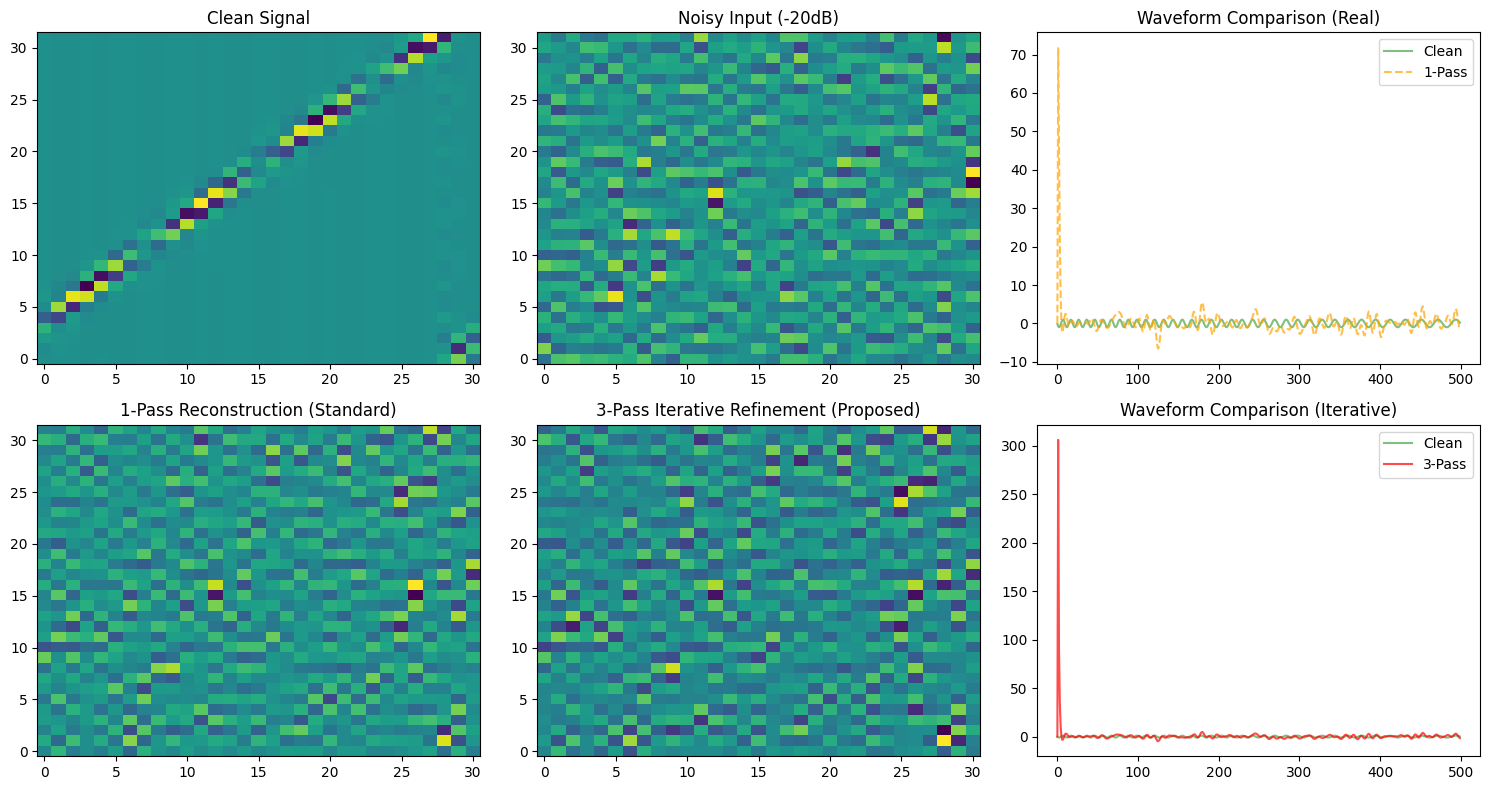

=== Performance Comparison (SNR: -20dB) ===
1. Standard (1-pass) MSE : 61.929664
2. Iterative (3-pass) MSE : 186.074867
   -> Improvement: -200.46% reduced error


In [13]:
#########################################################
##  6. Iterative Refinement (공명) 테스트              ##
##  - 노이즈가 심한 신호를 여러 번 통과시켜 정제          ##
#########################################################

# 1. 테스트용 노이즈 신호 생성 (-15dB ~ -25dB 사이 추천)
test_idx = 42  # 임의의 테스트 샘플 인덱스
target_snr = -20 # 극한 노이즈 환경 설정

clean_iq = X_clean_iq[test_idx] # 원본 (Clean)
noisy_iq = lora.awgn_iq(clean_iq, target_snr) # 노이즈 추가 (Noisy)

# 스펙트로그램 변환 (입력 준비)
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)
noisy_input = noisy_flat.reshape(1, -1) # (1, 1984)

# -------------------------------------------------------
# [비교 1] 기존 방식 (1회 통과)
# -------------------------------------------------------
# compress -> decompress
compressed_1 = model.compress(noisy_input)
restored_1 = model.decompress(compressed_1) 
iq_1 = reconstruct_iq_from_spectrogram(restored_1.flatten(), norm_params, fs)

# -------------------------------------------------------
# [비교 2] Iterative Refinement (3회 반복 공명)
# -------------------------------------------------------
# 새로 추가하신 메서드 호출
iterations = 3
restored_iter = model.iterative_reconstruction(noisy_input, iterations=iterations)
iq_iter = reconstruct_iq_from_spectrogram(restored_iter.flatten(), norm_params, fs)

# -------------------------------------------------------
# [시각화] 결과 비교
# -------------------------------------------------------
plt.figure(figsize=(15, 8))

# 1. Spectrogram 비교
plt.subplot(2, 3, 1)
plt.title("Clean Signal")
plt.imshow(generate_complex_spectrogram(clean_iq, fs, bw)[0][:len(noisy_flat)//2].reshape(32, -1), aspect='auto', origin='lower')

plt.subplot(2, 3, 2)
plt.title(f"Noisy Input ({target_snr}dB)")
plt.imshow(noisy_flat[:len(noisy_flat)//2].reshape(32, -1), aspect='auto', origin='lower')

plt.subplot(2, 3, 4)
plt.title("1-Pass Reconstruction (Standard)")
plt.imshow(restored_1.flatten()[:len(noisy_flat)//2].reshape(32, -1), aspect='auto', origin='lower')

plt.subplot(2, 3, 5)
plt.title(f"{iterations}-Pass Iterative Refinement (Proposed)")
plt.imshow(restored_iter.flatten()[:len(noisy_flat)//2].reshape(32, -1), aspect='auto', origin='lower')

# 2. Waveform (Real Part) 비교
plt.subplot(2, 3, 3)
plt.title("Waveform Comparison (Real)")
plt.plot(clean_iq.real[:500], label="Clean", alpha=0.5, color='green')
plt.plot(iq_1.real[:500], label="1-Pass", alpha=0.7, linestyle='--', color='orange')
plt.legend()

plt.subplot(2, 3, 6)
plt.title("Waveform Comparison (Iterative)")
plt.plot(clean_iq.real[:500], label="Clean", alpha=0.5, color='green')
plt.plot(iq_iter.real[:500], label=f"{iterations}-Pass", alpha=0.7, linestyle='-', color='red')
plt.legend()

plt.tight_layout()
plt.show()

# 정량적 평가 (MSE)
mse_1 = np.mean(np.abs(clean_iq - iq_1)**2)
mse_iter = np.mean(np.abs(clean_iq - iq_iter)**2)

print(f"=== Performance Comparison (SNR: {target_snr}dB) ===")
print(f"1. Standard (1-pass) MSE : {mse_1:.6f}")
print(f"2. Iterative ({iterations}-pass) MSE : {mse_iter:.6f}")
print(f"   -> Improvement: {((mse_1 - mse_iter)/mse_1)*100:.2f}% reduced error")